In [0]:
%pip install scikit-surprise

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
ratings = spark.read.csv(
    "/Volumes/agri_project/project/weather_data/ratings.csv",
    header=True, inferSchema=True
)

anime = spark.read.csv(
    "/Volumes/agri_project/project/weather_data/animes.csv",
    header=True, inferSchema=True
)

ratings.printSchema()
anime.printSchema()


root
 |-- userID: integer (nullable = true)
 |-- animeID: integer (nullable = true)
 |-- rating: integer (nullable = true)

root
 |-- animeID: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- alternative_title: string (nullable = true)
 |-- type: string (nullable = true)
 |-- year: string (nullable = true)
 |-- score: string (nullable = true)
 |-- episodes: double (nullable = true)
 |-- mal_url: string (nullable = true)
 |-- sequel: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- genres_detailed: string (nullable = true)



In [0]:
print(ratings.count(), anime.count())

148170496 20237


Run only once

In [0]:
# ═══════════════════════════════════════════════════
# SAVE AS DELTA TABLES — RUN ONCE ONLY
# After this cell runs successfully — NEVER run it again
# Comment it out or skip it in future sessions
# ═══════════════════════════════════════════════════

CATALOG = "agri_project"
SCHEMA  = "project"

print("Saving to Delta tables — run ONCE only...")
print("This will take 3–5 mins for 148M rows")
print("-" * 55)

# 1. Save raw ratings
ratings.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.ratings_raw")
print(f"✅ ratings_raw saved")

# 2. Save raw anime
anime.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.anime_raw")
print(f"✅ anime_raw saved")

print()
print("DONE — these tables now live permanently")
print("in Unity Catalog even after kernel restart")
print()
print("Next time kernel restarts → skip Cell 1 & 2")
print("Just run Cell 3 to reload everything instantly")

Saving to Delta tables — run ONCE only...
This will take 3–5 mins for 148M rows
-------------------------------------------------------
✅ ratings_raw saved
✅ anime_raw saved

DONE — these tables now live permanently
in Unity Catalog even after kernel restart

Next time kernel restarts → skip Cell 1 & 2
Just run Cell 3 to reload everything instantly


Run this cell after each start

In [0]:
# ═══════════════════════════════════════════════════
# RESTART RECOVERY CELL
# ═══════════════════════════════════════════════════
# Kernel restarted? Session timed out?
# Just run THIS cell — skip Cell 1 and Cell 2
# Loads everything in under 60 seconds
# ═══════════════════════════════════════════════════

from pyspark.sql.functions import col, count, avg, stddev
from pyspark.sql.functions import when, expr, trim, lit
from pyspark.sql.functions import explode, split, concat
from pyspark.sql.functions import count as spark_count
from pyspark.sql.functions import avg as spark_avg
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

CATALOG = "agri_project"
SCHEMA  = "project"

print("Loading from Delta tables...")
print("-" * 55)

# ── Step 1: Load raw tables ────────────────────────
ratings = spark.table(f"{CATALOG}.{SCHEMA}.ratings_raw")
anime   = spark.table(f"{CATALOG}.{SCHEMA}.anime_raw")
print(f"✅ ratings loaded : {ratings.count():,} rows")
print(f"✅ anime loaded   : {anime.count():,} rows")

# ── Step 2: Rebuild ratings_clean ─────────────────
# Remove -1 ratings + duplicates
ratings_clean = (ratings
    .filter(col("rating") > 0)
    .dropDuplicates(["userID", "animeID"])
)

# Remove users with less than 5 ratings
user_counts = (ratings_clean
    .groupBy("userID")
    .agg(spark_count("animeID").alias("rating_count"))
    .filter(col("rating_count") >= 5)
)
ratings_clean = ratings_clean.join(
    user_counts.select("userID"),
    on="userID", how="inner"
)
print(f"✅ ratings_clean  : {ratings_clean.count():,} rows")

# ── Step 3: Rebuild anime_clean ───────────────────
anime_clean = (anime
    .withColumn("score_float",
                expr("try_cast(score as float)"))
    .withColumn("episodes_int",
                expr("try_cast(episodes as int)"))
    .withColumn("year_int",
                expr("try_cast(year as int)"))
)

# Fix score — valid range only
anime_clean = anime_clean.withColumn(
    "score_float",
    when(
        (col("score_float") >= 1.0) &
        (col("score_float") <= 10.0),
        col("score_float")
    ).otherwise(None)
)

# Clean string columns
for c in ["title","type","genres","alternative_title"]:
    anime_clean = anime_clean.withColumn(
        c,
        when(
            col(c).isNull() |
            (trim(col(c)) == "") |
            (trim(col(c)) == "?"),
            None
        ).otherwise(trim(col(c)))
    )

# Add title_english column
anime_clean = anime_clean.withColumn(
    "title_english",
    when(
        col("alternative_title").isNotNull() &
        (col("alternative_title") != col("title")),
        concat(
            col("title"),
            lit(" ("),
            col("alternative_title"),
            lit(")")
        )
    ).otherwise(col("title"))
)

# Drop nulls on critical columns
anime_clean = anime_clean.dropna(
    subset=["animeID","title"])

# Keep only anime with at least 1 rating
anime_with_ratings = ratings_clean\
    .select("animeID").distinct()
anime_clean = anime_clean.join(
    anime_with_ratings, on="animeID", how="inner")

print(f"✅ anime_clean    : {anime_clean.count():,} rows")

# ── Step 4: Load checkpoint tables if they exist ──
try:
    ratings_clean_saved = spark.table(
        f"{CATALOG}.{SCHEMA}.ratings_clean")
    anime_clean_saved   = spark.table(
        f"{CATALOG}.{SCHEMA}.anime_clean_table")
    print(f"✅ ratings_clean checkpoint found")
    print(f"✅ anime_clean   checkpoint found")
except Exception:
    print("ℹ️  No checkpoints yet — will be created")
    print("    after you run the checkpoint save cell")

# ── Step 5: Load ML outputs if they exist ─────────
try:
    user_pd_elbow = spark.table(
        f"{CATALOG}.{SCHEMA}.user_clusters_delta"
    ).toPandas()
    print(f"✅ user_clusters  loaded from Delta"
          f" — {len(user_pd_elbow):,} rows")
except Exception:
    print("ℹ️  user_clusters not saved yet")
    user_pd_elbow = None

try:
    anime_pd = spark.table(
        f"{CATALOG}.{SCHEMA}.anime_pd_delta"
    ).toPandas()
    print(f"✅ anime_pd       loaded from Delta"
          f" — {len(anime_pd):,} rows")
except Exception:
    print("ℹ️  anime_pd not saved yet")
    anime_pd = None

print()
print("=" * 55)
print("ALL VARIABLES RESTORED ✅")
print("Continue from any cell in the notebook")
print("=" * 55)

Loading from Delta tables...
-------------------------------------------------------
✅ ratings loaded : 148,170,496 rows
✅ anime loaded   : 20,237 rows
✅ ratings_clean  : 144,672,105 rows
✅ anime_clean    : 20,237 rows
✅ ratings_clean checkpoint found
✅ anime_clean   checkpoint found
✅ user_clusters  loaded from Delta — 50,261 rows
ℹ️  anime_pd not saved yet

ALL VARIABLES RESTORED ✅
Continue from any cell in the notebook


##Basic EDA

Schema

In [0]:
print("=" * 60)
print("RATINGS SCHEMA")
print("=" * 60)
ratings.printSchema()

print("=" * 60)
print("ANIMES SCHEMA")
print("=" * 60)
anime.printSchema()

RATINGS SCHEMA
root
 |-- userID: integer (nullable = true)
 |-- animeID: integer (nullable = true)
 |-- rating: integer (nullable = true)

ANIMES SCHEMA
root
 |-- animeID: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- alternative_title: string (nullable = true)
 |-- type: string (nullable = true)
 |-- year: string (nullable = true)
 |-- score: string (nullable = true)
 |-- episodes: double (nullable = true)
 |-- mal_url: string (nullable = true)
 |-- sequel: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- genres_detailed: string (nullable = true)



 Row counts & basic stats

In [0]:
print(f"Ratings rows : {ratings.count():,}")
print(f"Animes rows  : {anime.count():,}")
print()

# Unique counts
from pyspark.sql.functions import countDistinct, col, avg, min as spark_min, max as spark_max

ratings.select(
    countDistinct("userID").alias("unique_users"),
    countDistinct("animeID").alias("unique_anime"),
    spark_min("rating").alias("min_rating"),
    spark_max("rating").alias("max_rating"),
    avg("rating").alias("avg_rating")
).show()

Ratings rows : 148,170,496
Animes rows  : 20,237

+------------+------------+----------+----------+----------------+
|unique_users|unique_anime|min_rating|max_rating|      avg_rating|
+------------+------------+----------+----------+----------------+
|     1774522|       20237|         0|        10|7.64512578131614|
+------------+------------+----------+----------+----------------+



Rating distribution

Rating distribution:
    rating     count
0        0    106281
1        1   1669398
2        2   1306523
3        3   1880375
4        4   4825252
5        5   7000477
6        6  15976175
7        7  28590614
8        8  37188066
9        9  21214109
10      10  28413226


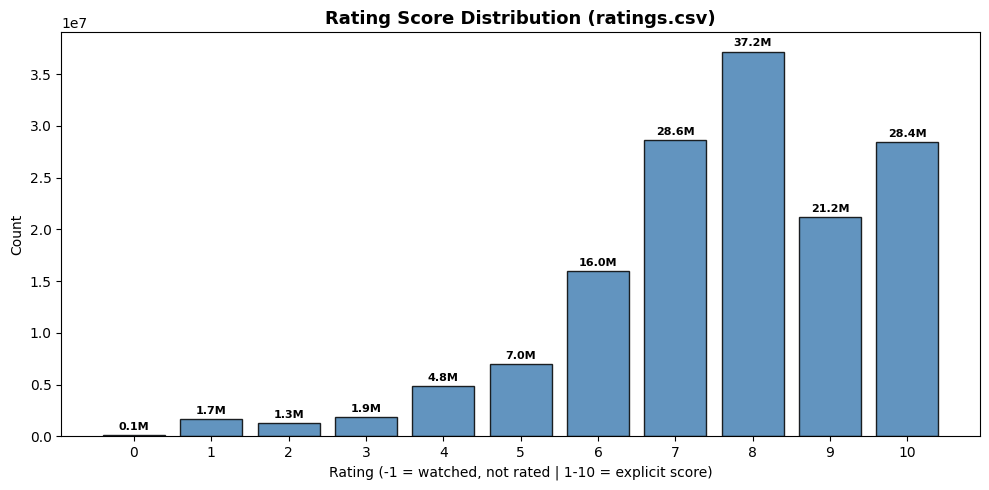

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Rating value counts
rating_dist = (ratings
    .groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

print("Rating distribution:")
print(rating_dist)

plt.figure(figsize=(10, 5))
plt.bar(rating_dist["rating"].astype(str), rating_dist["count"],
        color="steelblue", edgecolor="black", alpha=0.85)
plt.title("Rating Score Distribution (ratings.csv)", fontsize=13, fontweight="bold")
plt.xlabel("Rating (-1 = watched, not rated | 1-10 = explicit score)")
plt.ylabel("Count")
plt.xticks(rotation=0)
for i, row in rating_dist.iterrows():
    plt.text(i, row["count"] + 500000, f'{row["count"]/1e6:.1f}M',
             ha="center", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

Anime type & genre distribution

In [0]:
from pyspark.sql.functions import split, explode, trim

# Type distribution
print("Anime by Type:")
anime.groupBy("type").count().orderBy("count", ascending=False).show()

# Year distribution
print("Anime by Year (top 20):")
anime.groupBy("year").count().orderBy("count", ascending=False).show(20)

Anime by Type:
+--------------------+-----+
|                type|count|
+--------------------+-----+
|                  TV| 5759|
|             SPECIAL| 4845|
|                 OVA| 3660|
|               MOVIE| 3249|
|                 ONA| 2713|
|                NULL|    2|
| Nonbiri Onsen Te...|    1|
|   Annai Shitemita."|    1|
|"Himesama ""Goumo...|    1|
|  Igi Ari! Season 2"|    1|
|"Himesama ""Goumo...|    1|
|           Igi Ari!"|    1|
|"Fuguushoku ""Kan...|    1|
| Neko to Machigaw...|    1|
|"Holoearth Anime ...|    1|
+--------------------+-----+

Anime by Year (top 20):
+----+-----+
|year|count|
+----+-----+
|2021|  900|
|2017|  894|
|2016|  886|
|2018|  876|
|2022|  874|
|2019|  864|
|2023|  832|
|2020|  811|
|2014|  799|
|2015|  758|
|2024|  743|
|2013|  705|
|2012|  695|
|2011|  651|
|2009|  554|
|2010|  553|
|2006|  463|
|2008|  460|
|2007|  441|
|2005|  387|
+----+-----+
only showing top 20 rows


Genre breakdown

              genre  count
0         ['Action'   4776
1         ['Comedy'   2659
2        'Fantasy']   2448
3         'Sci-Fi']   2411
4        ['Comedy']   2223
5       'Adventure'   1702
6      ['Adventure'   1565
7          'Comedy'   1497
8        ['Hentai']   1304
9   'Supernatural']   1146
10       'Romance']   1128
11        'Fantasy'   1104
12          'Drama'   1075
13         ['Drama'    849
14      ['Fantasy']    821


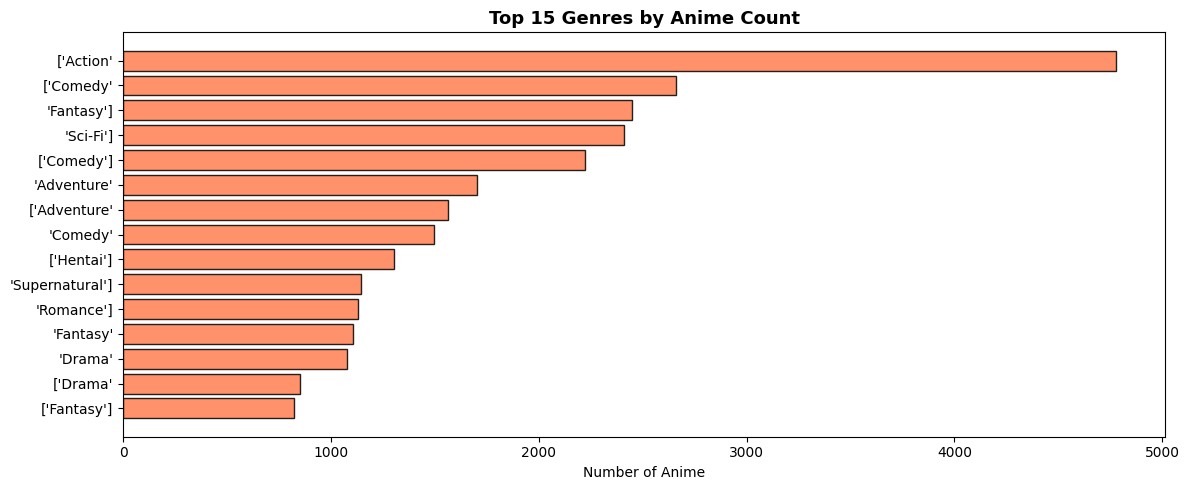

In [0]:
from pyspark.sql.functions import split, explode, trim, col

# genres column has comma-separated values — explode into rows
genre_df = (anime
    .select(explode(split(col("genres"), ",")).alias("genre"))
    .select(trim(col("genre")).alias("genre"))
    .groupBy("genre")
    .count()
    .orderBy("count", ascending=False)
)

genre_pd = genre_df.toPandas().head(15)
print(genre_pd)

plt.figure(figsize=(12, 5))
plt.barh(genre_pd["genre"][::-1], genre_pd["count"][::-1],
         color="coral", edgecolor="black", alpha=0.85)
plt.title("Top 15 Genres by Anime Count", fontsize=13, fontweight="bold")
plt.xlabel("Number of Anime")
plt.tight_layout()
plt.show()

Score distribution

Valid scores     : 19,633
Mean score       : 6.32
Min / Max        : 1.7300000190734863 / 10.0


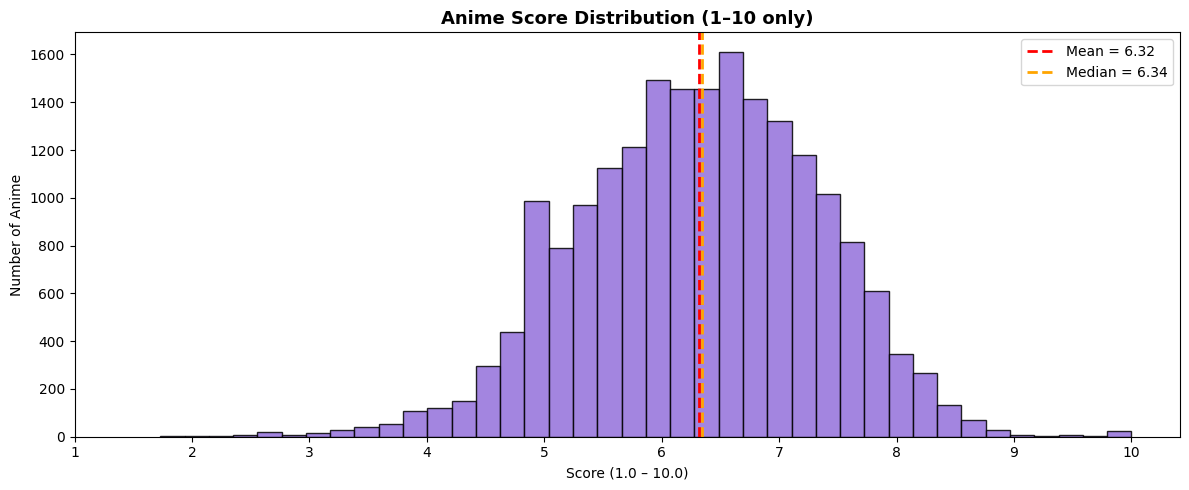

In [0]:
from pyspark.sql.functions import col, expr
import warnings
warnings.filterwarnings("ignore")

# Filter to valid score range 1.0 to 10.0 only
# This removes year values (1970, 2026) and other garbage mixed into the column
anime_scores = (anime
    .withColumn("score_float", expr("try_cast(score as float)"))
    .filter(col("score_float").isNotNull())
    .filter(col("score_float") >= 1.0)
    .filter(col("score_float") <= 10.0)
    .select("score_float")
    .toPandas()
)

print(f"Valid scores     : {len(anime_scores):,}")
print(f"Mean score       : {anime_scores['score_float'].mean():.2f}")
print(f"Min / Max        : {anime_scores['score_float'].min()} / {anime_scores['score_float'].max()}")

plt.figure(figsize=(12, 5))
plt.hist(anime_scores["score_float"], bins=40,
         color="mediumpurple", edgecolor="black", alpha=0.85)
plt.axvline(anime_scores["score_float"].mean(), color="red",
            linestyle="--", linewidth=2,
            label=f'Mean = {anime_scores["score_float"].mean():.2f}')
plt.axvline(anime_scores["score_float"].median(), color="orange",
            linestyle="--", linewidth=2,
            label=f'Median = {anime_scores["score_float"].median():.2f}')
plt.title("Anime Score Distribution (1–10 only)", fontsize=13, fontweight="bold")
plt.xlabel("Score (1.0 – 10.0)")
plt.ylabel("Number of Anime")
plt.xticks([1,2,3,4,5,6,7,8,9,10])
plt.legend()
plt.tight_layout()
plt.show()

Missing values

In [0]:
from pyspark.sql.functions import col, count, when

# ratings — no type issues, straightforward
print("Missing values — ratings:")
ratings.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in ratings.columns
]).show()

# animes — all columns treated as string to avoid cast errors
print("Missing values — animes:")
anime.select([
    count(when(
        col(c).isNull() | (col(c).cast("string") == "") | (col(c).cast("string") == "?"),
        c
    )).alias(c)
    for c in anime.columns
]).show()

Missing values — ratings:
+------+-------+------+
|userID|animeID|rating|
+------+-------+------+
|     0|      0|     0|
+------+-------+------+

Missing values — animes:
+-------+-----+-----------------+----+----+-----+--------+-------+------+---------+------+---------------+
|animeID|title|alternative_title|type|year|score|episodes|mal_url|sequel|image_url|genres|genres_detailed|
+-------+-----+-----------------+----+----+-----+--------+-------+------+---------+------+---------------+
|      0|    0|            11559|   2| 136|  593|       0|      0|     0|        0|     0|              0|
+-------+-----+-----------------+----+----+-----+--------+-------+------+---------+------+---------------+



Top rated & most popular anime

In [0]:
from pyspark.sql.functions import expr, col

# Top anime by score — use try_cast + filter valid range
print("Top 10 highest rated anime:")
(anime
 .withColumn("score_float", expr("try_cast(score as float)"))
 .filter(col("score_float").isNotNull())
 .filter(col("score_float") >= 1.0)
 .filter(col("score_float") <= 10.0)
 .orderBy("score_float", ascending=False)
 .select("title", "type", "year", "score", "genres")
 .show(10, truncate=40)
)

Top 10 highest rated anime:
+----------------------------------------+-----+----+-----+----------------------------------------+
|                                   title| type|year|score|                                  genres|
+----------------------------------------+-----+----+-----+----------------------------------------+
|Campfire Cooking in Another World wit...|   TV|2025|   10|['Adventure', 'Comedy', 'Fantasy', 'G...|
|     Boku no Kokoro no Yabai Yatsu Movie|MOVIE|   ?|   10|                   ['Comedy', 'Romance']|
|Disney: Twisted-Wonderland The Animat...|  ONA|2025|   10|                                      []|
|Seishun Buta Yarou wa Santa Claus no ...|   TV|2025|   10|    ['Drama', 'Romance', 'Supernatural']|
|            Grand Blue Dreaming Season 2|   TV|2025|   10|                              ['Comedy']|
|                       Omniscient Reader|   TV|   ?|   10|      ['Action', 'Adventure', 'Fantasy']|
|Youkoso Jitsuryoku Shijou Shugi no Ky...|   TV|   ?|   10|    

User activity distribution

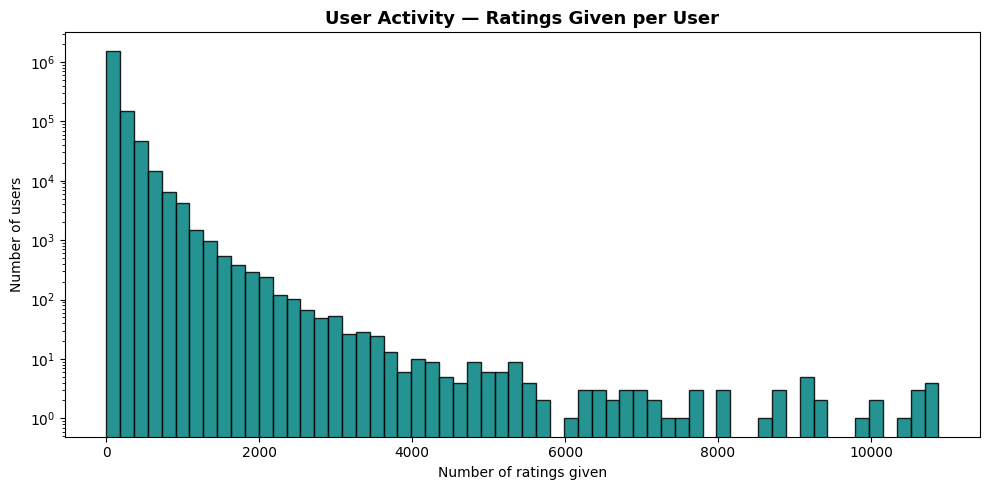


User activity stats:
count    1.774493e+06
mean     8.344029e+01
std      1.558318e+02
min      1.000000e+00
25%      1.000000e+01
50%      2.900000e+01
75%      9.200000e+01
max      1.088100e+04
Name: ratings_given, dtype: float64


In [0]:
from pyspark.sql.functions import count as spark_count

user_activity = (ratings
    .filter(col("rating") > 0)           # explicit ratings only
    .groupBy("userID")
    .agg(spark_count("animeID").alias("ratings_given"))
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.hist(user_activity["ratings_given"], bins=60,
         color="teal", edgecolor="black", alpha=0.85)
plt.title("User Activity — Ratings Given per User", fontsize=13, fontweight="bold")
plt.xlabel("Number of ratings given")
plt.ylabel("Number of users")
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"\nUser activity stats:")
print(user_activity["ratings_given"].describe())

Anime popularity

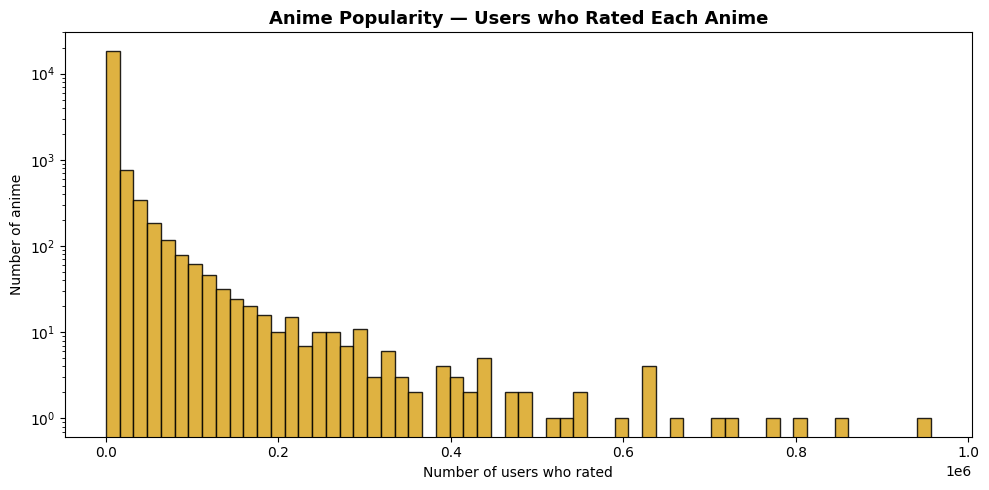


Top 5 most rated anime:
----------------------------------------------------------------------
                            title  user_count  score_float                                            genres
1                 Attack on Titan      956399         8.57  ['Action', 'Award Winning', 'Drama', 'Suspense']
2                      Death Note      854690         8.63                      ['Supernatural', 'Suspense']
3                My Hero Academia      805562         8.10                                        ['Action']
4                   One Punch Man      772666         8.55                              ['Action', 'Comedy']
5  Demon Slayer: Kimetsu no Yaiba      728924         8.57       ['Action', 'Award Winning', 'Supernatural']


In [0]:
from pyspark.sql.functions import count as spark_count, expr, col

# Define anime_clean here (in case it wasn't run earlier)
anime_clean = (anime
    .withColumn("score_float", expr("try_cast(score as float)"))
    .withColumn("episodes_int", expr("try_cast(episodes as int)"))
    .withColumn("year_int", expr("try_cast(year as int)"))
)

# Popularity count per anime
anime_popularity = (ratings
    .filter(col("rating") > 0)
    .groupBy("animeID")
    .agg(spark_count("userID").alias("user_count"))
)

# Join with anime to get titles
anime_popularity_named = (anime_popularity
    .join(
        anime_clean.select("animeID", "title", "score_float", "genres"),
        on="animeID", how="left"
    )
    .orderBy("user_count", ascending=False)
)

# Convert to pandas for plotting
pop_pd = anime_popularity_named.toPandas()

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(pop_pd["user_count"], bins=60,
         color="goldenrod", edgecolor="black", alpha=0.85)
plt.title("Anime Popularity — Users who Rated Each Anime", fontsize=13, fontweight="bold")
plt.xlabel("Number of users who rated")
plt.ylabel("Number of anime")
plt.yscale("log")
plt.tight_layout()
plt.show()

# Top 5 most rated anime with names
print("\nTop 5 most rated anime:")
print("-" * 70)
top5 = pop_pd.head(5)[["title", "user_count", "score_float", "genres"]]
top5.index = range(1, 6)
print(top5.to_string())

##Cleaning 

Remove ratings with value -1

In [0]:
from pyspark.sql.functions import col

# -1 means user watched but never gave a score — useless for recommendation model
ratings_clean = ratings.filter(col("rating") > 0)

print(f"Original ratings : {ratings.count():,}")
print(f"After removing -1: {ratings_clean.count():,}")
print(f"Removed          : {ratings.count() - ratings_clean.count():,}")

Original ratings : 148,170,496
After removing -1: 148,064,215
Removed          : 106,281


Remove Duplicates

In [0]:
before = ratings_clean.count()
ratings_clean = ratings_clean.dropDuplicates(["userID", "animeID"])
after = ratings_clean.count()

print(f"Before dedup : {before:,}")
print(f"After dedup  : {after:,}")
print(f"Removed      : {before - after:,} duplicate user-anime pairs")

Before dedup : 148,064,215
After dedup  : 144,679,503
Removed      : 3,384,712 duplicate user-anime pairs


Clean anime dataframe

In [0]:
from pyspark.sql.functions import expr, col, trim, when

# Step 1: safe cast score, episodes, year
anime_clean = (anime
    .withColumn("score_float",   expr("try_cast(score as float)"))
    .withColumn("episodes_int",  expr("try_cast(episodes as int)"))
    .withColumn("year_int",      expr("try_cast(year as int)"))
)

# Step 2: filter score to valid range 1-10
anime_clean = anime_clean.withColumn(
    "score_float",
    when((col("score_float") >= 1.0) & (col("score_float") <= 10.0),
         col("score_float")).otherwise(None)
)

# Step 3: trim whitespace from string columns
for c in ["title", "type", "genres", "genres_detailed"]:
    anime_clean = anime_clean.withColumn(c, trim(col(c)))

# Step 4: replace empty strings and '?' with null
from pyspark.sql.functions import nullif
for c in ["title", "type", "genres", "year", "score", "episodes"]:
    anime_clean = anime_clean.withColumn(
        c,
        when((col(c) == "") | (col(c) == "?"), None).otherwise(col(c))
    )

print("anime_clean schema after cleaning:")
anime_clean.printSchema()

anime_clean schema after cleaning:
root
 |-- animeID: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- alternative_title: string (nullable = true)
 |-- type: string (nullable = true)
 |-- year: string (nullable = true)
 |-- score: string (nullable = true)
 |-- episodes: double (nullable = true)
 |-- mal_url: string (nullable = true)
 |-- sequel: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- genres_detailed: string (nullable = true)
 |-- score_float: float (nullable = true)
 |-- episodes_int: integer (nullable = true)
 |-- year_int: integer (nullable = true)



 Drop rows where critical columns are null

In [0]:
# animeID and title are critical — drop if missing
before = anime_clean.count()
anime_clean = anime_clean.dropna(subset=["animeID", "title"])
after = anime_clean.count()

print(f"Anime before : {before:,}")
print(f"Anime after  : {after:,}")
print(f"Dropped      : {before - after:,} rows with null animeID or title")

Anime before : 20,237
Anime after  : 20,237
Dropped      : 0 rows with null animeID or title


Remove anime with no ratings at all

In [0]:
# Keep only anime that actually have user ratings
anime_with_ratings = ratings_clean.select("animeID").distinct()

before = anime_clean.count()
anime_clean = anime_clean.join(anime_with_ratings, on="animeID", how="inner")
after = anime_clean.count()

print(f"Anime before : {before:,}")
print(f"Anime after  : {after:,}")
print(f"Removed      : {before - after:,} anime with zero ratings")

Anime before : 20,237
Anime after  : 20,237
Removed      : 0 anime with zero ratings


Filter out inactive users(less than 5 ratings)

In [0]:
from pyspark.sql.functions import count as spark_count

# Users with very few ratings give unreliable recommendations
user_counts = (ratings_clean
    .groupBy("userID")
    .agg(spark_count("animeID").alias("rating_count"))
    .filter(col("rating_count") >= 5)
)

before = ratings_clean.count()
ratings_clean = ratings_clean.join(user_counts.select("userID"), on="userID", how="inner")
after = ratings_clean.count()

print(f"Ratings before : {before:,}")
print(f"Ratings after  : {after:,}")
print(f"Removed        : {before - after:,} ratings from users with < 5 ratings")
print(f"Active users   : {user_counts.count():,}")

Ratings before : 144,679,503
Ratings after  : 144,672,105
Removed        : 7,398 ratings from users with < 5 ratings
Active users   : 1,772,321


Add English title + image 

In [0]:
from pyspark.sql.functions import col, when, concat, lit, trim

# Step 1: Clean alternative_title column
anime_clean = anime_clean.withColumn(
    "alternative_title",
    when(
        col("alternative_title").isNull() |
        (trim(col("alternative_title")) == "") |
        (trim(col("alternative_title")) == "?"),
        None
    ).otherwise(trim(col("alternative_title")))
)

# Step 2: Build title_english column
# Format: "進撃の巨人 (Attack on Titan)"
# If no alternative title → just use original title
anime_clean = anime_clean.withColumn(
    "title_english",
    when(
        col("alternative_title").isNotNull() &
        (col("alternative_title") != col("title")),
        concat(
            col("title"),
            lit(" ("),
            col("alternative_title"),
            lit(")")
        )
    ).otherwise(col("title"))
)

# Step 3: Clean image_url column
anime_clean = anime_clean.withColumn(
    "image_url",
    when(
        col("image_url").isNull() |
        (trim(col("image_url")) == ""),
        None
    ).otherwise(trim(col("image_url")))
)

# Step 4: Verify results
print("Sample — title_english column:")
print("=" * 70)
anime_clean.select("title", "alternative_title", "title_english")\
    .filter(col("alternative_title").isNotNull())\
    .show(15, truncate=70)

print("Image URL coverage:")
total     = anime_clean.count()
has_image = anime_clean.filter(col("image_url").isNotNull()).count()
print(f"  Total anime      : {total:,}")
print(f"  With image URL   : {has_image:,}")
print(f"  Missing image    : {total - has_image:,}")
print(f"  Coverage         : {has_image/total*100:.1f}%")

Sample — title_english column:
+------------------------------------------------------------+-----------------------------------------------+----------------------------------------------------------------------+
|                                                       title|                              alternative_title|                                                         title_english|
+------------------------------------------------------------+-----------------------------------------------+----------------------------------------------------------------------+
|                                        Howl's Moving Castle|                            Howl no Ugoku Shiro|                            Howl's Moving Castle (Howl no Ugoku Shiro)|
|Problem Children Are Coming from Another World, Aren't They?|Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?|Problem Children Are Coming from Another World, Aren't They? (Monda...|
|                                                     BTOOO

In [0]:
# Preview top 10 anime with cover images inside Databricks
top_anime_images = (
    anime_clean
    .filter(col("image_url").isNotNull())
    .filter(col("score_float").isNotNull())
    .orderBy("score_float", ascending=False)
    .select("title", "title_english", "score_float", "image_url", "genres")
    .limit(10)
    .toPandas()
)

html = "<h3>Top Anime by Score — with Cover Art</h3>"
html += "<div style='display:flex; flex-wrap:wrap; gap:15px; padding:10px;'>"
for _, row in top_anime_images.iterrows():
    html += f"""
    <div style='text-align:center; width:140px; 
                background:#1a1a2e; border-radius:10px; 
                padding:8px; color:white;'>
        <img src='{row["image_url"]}'
             width='120' height='170'
             style='border-radius:6px; object-fit:cover;'
             onerror="this.src='https://via.placeholder.com/120x170?text=No+Image'"/>
        <p style='font-size:10px; margin-top:6px; font-weight:bold;'>
            {str(row["title_english"])[:25]}
        </p>
        <p style='font-size:11px; color:#f2c811;'>
            ⭐ {row["score_float"]:.1f}
        </p>
        <p style='font-size:9px; color:#aaa;'>
            {str(row["genres"])[:30]}
        </p>
    </div>"""
html += "</div>"

displayHTML(html)

Top Anime by Score — with Cover Art 
 
 
 
 Boku no Kokoro no Yabai Y
 
 
 ⭐ 10.0
 
 
 ['Comedy', 'Romance']
 
 
 
 
 
 Fire Force Season 3 Part 
 
 
 ⭐ 10.0
 
 
 ['Action', 'Fantasy', 'Sci-Fi'
 
 
 
 
 
 Youkoso Jitsuryoku Shijou
 
 
 ⭐ 10.0
 
 
 ['Drama', 'Suspense']
 
 
 
 
 
 Tensei shitara Slime Datt
 
 
 ⭐ 10.0
 
 
 ['Action', 'Comedy', 'Fantasy'
 
 
 
 
 
 Disney: Twisted-Wonderlan
 
 
 ⭐ 10.0
 
 
 []
 
 
 
 
 
 Omniscient Reader (Zenchi
 
 
 ⭐ 10.0
 
 
 ['Action', 'Adventure', 'Fanta
 
 
 
 
 
 Yozakura-san Chi no Daisa
 
 
 ⭐ 10.0
 
 
 ['Action', 'Comedy']
 
 
 
 
 
 Campfire Cooking in Anoth
 
 
 ⭐ 10.0
 
 
 ['Adventure', 'Comedy', 'Fanta
 
 
 
 
 
 Grand Blue Dreaming Seaso
 
 
 ⭐ 10.0
 
 
 ['Comedy']
 
 
 
 
 
 Seishun Buta Yarou wa San
 
 
 ⭐ 10.0
 
 
 ['Drama', 'Romance', 'Supernat

Final cleaning summary

In [0]:
print("=" * 55)
print("CLEANING SUMMARY")
print("=" * 55)
print(f"Original ratings     : {ratings.count():>15,}")
print(f"Clean ratings        : {ratings_clean.count():>15,}")
print(f"Reduction            : {(1 - ratings_clean.count()/ratings.count())*100:.1f}%")
print()
print(f"Original anime       : {anime.count():>15,}")
print(f"Clean anime          : {anime_clean.count():>15,}")
print()
print(f"Unique clean users   : {ratings_clean.select('userID').distinct().count():>15,}")
print(f"Unique clean anime   : {ratings_clean.select('animeID').distinct().count():>15,}")

# Rating distribution after cleaning
print("\nRating distribution after cleaning:")
(ratings_clean
 .groupBy("rating")
 .count()
 .orderBy("rating")
 .show()
)

CLEANING SUMMARY
Original ratings     :     148,170,496
Clean ratings        :     144,672,105
Reduction            : 2.4%

Original anime       :          20,237
Clean anime          :          20,237

Unique clean users   :       1,772,321
Unique clean anime   :          20,237

Rating distribution after cleaning:
+------+--------+
|rating|   count|
+------+--------+
|     1| 1643795|
|     2| 1273362|
|     3| 1834076|
|     4| 4726660|
|     5| 6828737|
|     6|15596059|
|     7|27949579|
|     8|36298809|
|     9|20653902|
|    10|27867126|
+------+--------+



Check Point 1

In [0]:
# ── CHECKPOINT 1 — Save after cleaning ─────────────────────────────
# Run after all cleaning cells are complete
# Next session → Cell 3 loads these instantly from Delta

from pyspark.sql.functions import col, when, expr
from pyspark.sql.types import DoubleType, FloatType, IntegerType, LongType

CATALOG = "agri_project"
SCHEMA  = "project"

print("Saving cleaning checkpoint...")

# ── Fix anime_clean here with correct try_cast syntax ──────────────
# try_cast must be inside expr() — it is Spark SQL, not Python
anime_fixed = (anime
    .withColumn("score_float",   expr("try_cast(score as float)"))
    .withColumn("episodes_int",  expr("try_cast(episodes as int)"))
    .withColumn("year_int",      expr("try_cast(year as int)"))
    # filter score to valid range 1–10
    .withColumn("score_float",
        when(
            (col("score_float") >= 1.0) & (col("score_float") <= 10.0),
            col("score_float")
        ).otherwise(None)
    )
    # clean string columns
    .withColumn("genres",
        when((col("genres").isNull()) | (col("genres") == "") | (col("genres") == "?"),
             None).otherwise(col("genres")))
    .withColumn("type",
        when((col("type").isNull()) | (col("type") == "") | (col("type") == "?"),
             None).otherwise(col("type")))
    .withColumn("title",
        when((col("title").isNull()) | (col("title") == ""),
             None).otherwise(col("title")))
    # add english title from alternative_title
    .withColumn("title_english",
        when(
            col("alternative_title").isNotNull() &
            (col("alternative_title") != "") &
            (col("alternative_title") != col("title")),
            expr("concat(title, ' (', alternative_title, ')')")
        ).otherwise(col("title"))
    )
    # clean image_url
    .withColumn("image_url",
        when(
            col("image_url").isNull() | (col("image_url") == ""),
            None
        ).otherwise(col("image_url"))
    )
    .dropna(subset=["animeID", "title"])
)

# Save ratings table
ratings_clean.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.ratings_clean")
print("✅ ratings_clean saved to Delta")

# Save anime table
anime_fixed.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.anime_clean_table")
print("✅ anime_clean saved to Delta")

# Make anime_fixed available as anime_clean for all future cells
anime_clean = anime_fixed

print()
print("Checkpoint 1 complete ✅")
print("Next restart → Cell 3 loads these instantly")
print()
print("Quick check:")
print(f"  ratings_clean rows : {ratings_clean.count():,}")
print(f"  anime_clean rows   : {anime_clean.count():,}")

Saving cleaning checkpoint...
✅ ratings_clean saved to Delta
✅ anime_clean saved to Delta

Checkpoint 1 complete ✅
Next restart → Cell 3 loads these instantly

Quick check:
  ratings_clean rows : 144,672,105
  anime_clean rows   : 20,237


##Machine Learning Models

###Task 1 — User Behavior Analysis

Build user feature matrix

In [0]:
from pyspark.sql.functions import col, count, avg, stddev, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Build user-level features from ratings_clean
user_features = (ratings_clean
    .groupBy("userID")
    .agg(
        count("animeID").alias("total_ratings"),
        avg("rating").alias("avg_rating"),
        stddev("rating").alias("std_rating"),
        avg(when(col("rating") >= 8, 1).otherwise(0)).alias("high_rate_ratio"),
        avg(when(col("rating") <= 4, 1).otherwise(0)).alias("low_rate_ratio")
    )
    .fillna(0)
)

print("User feature matrix:")
user_features.show(5)
print(f"Total users: {user_features.count():,}")

User feature matrix:
+------+-------------+------------------+------------------+------------------+--------------------+
|userID|total_ratings|        avg_rating|        std_rating|   high_rate_ratio|      low_rate_ratio|
+------+-------------+------------------+------------------+------------------+--------------------+
|  2030|          379| 7.846965699208443|1.4245801484470586|0.6068601583113457|0.013192612137203167|
| 13218|          135|7.9037037037037035|1.2209249862301557|0.5777777777777777|                 0.0|
| 40000|          462|7.1103896103896105|1.7310298928547991|0.4523809523809524| 0.06926406926406926|
| 47009|           30| 8.766666666666667|0.9714309861845775|0.9333333333333333|                 0.0|
| 62591|          113| 7.610619469026549|1.6444366616748818| 0.584070796460177| 0.05309734513274336|
+------+-------------+------------------+------------------+------------------+--------------------+
only showing top 5 rows
Total users: 1,772,321


Scale features for clustering

In [0]:
# Assemble all features into one vector column
feature_cols = ["total_ratings", "avg_rating", "std_rating",
                "high_rate_ratio", "low_rate_ratio"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                           withStd=True, withMean=True)

user_assembled = assembler.transform(user_features)
scaler_model   = scaler.fit(user_assembled)
user_scaled    = scaler_model.transform(user_assembled)

print("Features assembled and scaled ✅")
user_scaled.select("userID", "features").show(3, truncate=50)

Features assembled and scaled ✅
+------+--------------------------------------------------+
|userID|                                          features|
+------+--------------------------------------------------+
|  2030|[2.0164003681211247,-0.2980885314844948,0.04805...|
| 13218|[0.3618979132424984,-0.2527983574200063,-0.2007...|
| 40000|[2.5792024326904937,-0.8860482169036715,0.42250...|
+------+--------------------------------------------------+
only showing top 3 rows


Step 1: Building user features...
  Users: 1,772,321 ✅
Step 2: Sampling to pandas...
  Sample size: 50,261 ✅
Step 3: Running elbow method...
  K=2 | Inertia=162,889
  K=3 | Inertia=121,354
  K=4 | Inertia=96,998
  K=5 | Inertia=81,740
  K=6 | Inertia=69,147
  K=7 | Inertia=62,299
  K=8 | Inertia=55,568


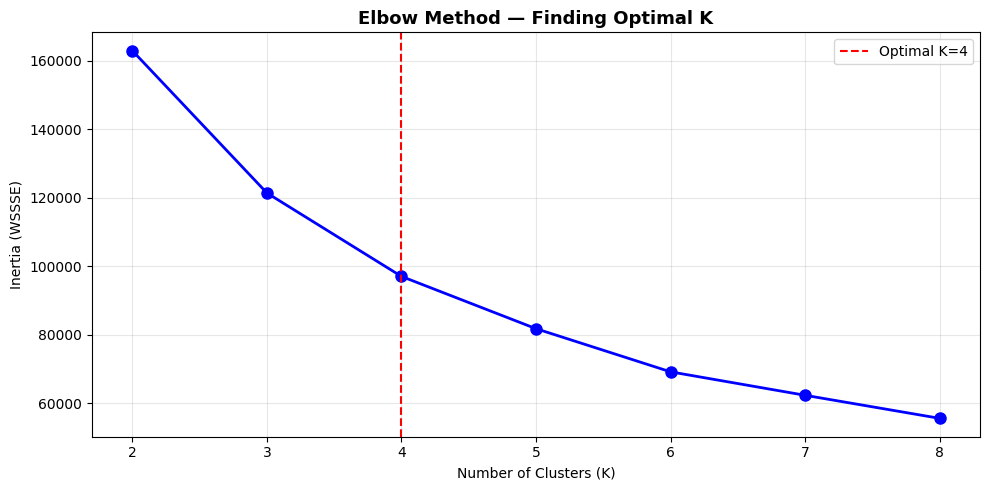

Elbow done ✅
Step 4: Training K-Means K=4...
  Silhouette Score : 0.3623 ✅
  Cluster sizes    : {0: 20979, 1: 22721, 2: 3038, 3: 3523}
Step 5: PCA visualization...


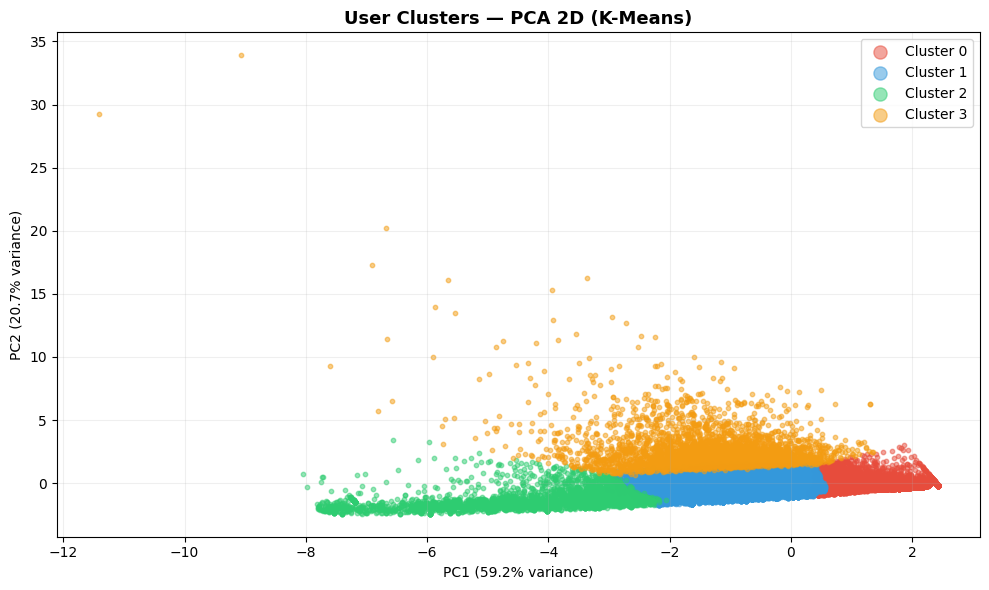

  PCA variance explained: 79.9% ✅
Step 6: Running DBSCAN on 20K sample...
  Clusters : 3 | Outliers : 86 ✅


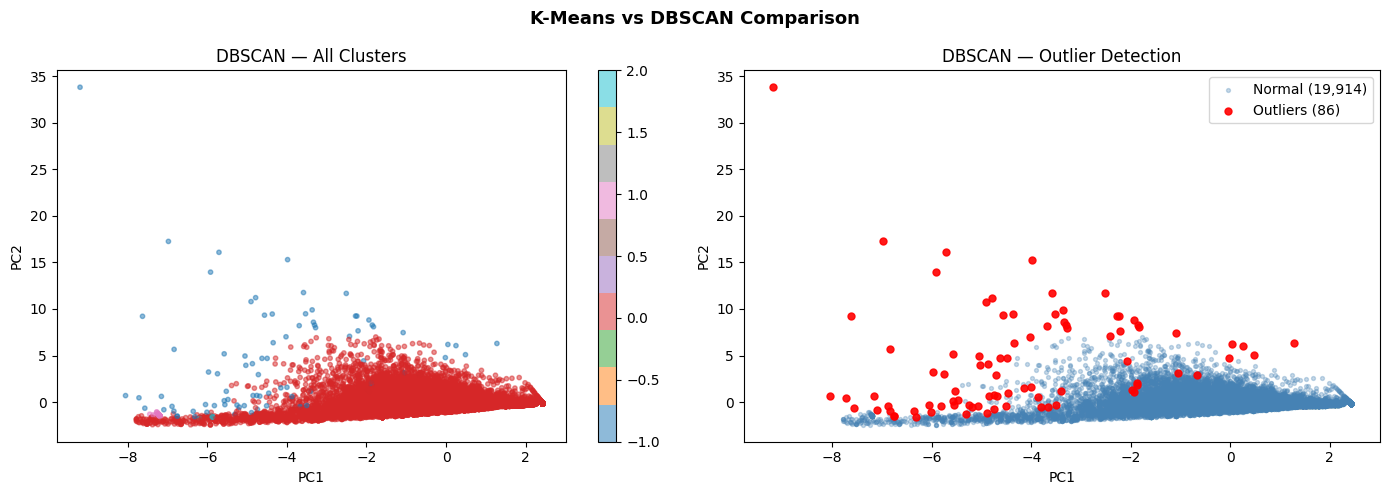


TASK 1 — COMPLETE SUMMARY
K-Means  | Clusters: 4 | Silhouette: 0.3623
DBSCAN   | Clusters: 3 auto | Outliers: 86
✅ Task 1 complete — ready for Task 2


In [0]:
from pyspark.sql.functions import col, count, avg, stddev, when
from sklearn.cluster import KMeans as SkKMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── STEP 1: Rebuild user_features from ratings_clean ──────────────────
print("Step 1: Building user features...")
user_features = (ratings_clean
    .groupBy("userID")
    .agg(
        count("animeID").alias("total_ratings"),
        avg("rating").alias("avg_rating"),
        stddev("rating").alias("std_rating"),
        avg(when(col("rating") >= 8, 1).otherwise(0)).alias("high_rate_ratio"),
        avg(when(col("rating") <= 4, 1).otherwise(0)).alias("low_rate_ratio")
    )
    .fillna(0)
)
print(f"  Users: {user_features.count():,} ✅")

# ── STEP 2: Sample to pandas (50K max) ────────────────────────────────
print("Step 2: Sampling to pandas...")
total_users = user_features.count()
frac = min(1.0, 50000 / total_users)
user_pd_elbow = user_features.sample(fraction=frac, seed=42).toPandas().fillna(0)
print(f"  Sample size: {len(user_pd_elbow):,} ✅")

feature_cols  = ["total_ratings", "avg_rating", "std_rating",
                 "high_rate_ratio", "low_rate_ratio"]
X             = user_pd_elbow[feature_cols].values
X_scaled      = StandardScaler().fit_transform(X)

# ── STEP 3: Elbow method ───────────────────────────────────────────────
print("Step 3: Running elbow method...")
wssse_list = []
k_range    = range(2, 9)
for k in k_range:
    km = SkKMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    km.fit(X_scaled)
    wssse_list.append(km.inertia_)
    print(f"  K={k} | Inertia={km.inertia_:,.0f}")

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), wssse_list, "bo-", linewidth=2, markersize=8)
plt.axvline(x=4, color="red", linestyle="--", label="Optimal K=4")
plt.title("Elbow Method — Finding Optimal K", fontsize=13, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WSSSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Elbow done ✅")

# ── STEP 4: K-Means final model ────────────────────────────────────────
print("Step 4: Training K-Means K=4...")
kmeans_sk = SkKMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
user_pd_elbow["cluster"] = kmeans_sk.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, user_pd_elbow["cluster"],
                             sample_size=10000, random_state=42)
print(f"  Silhouette Score : {sil_score:.4f} ✅")
print(f"  Cluster sizes    : {user_pd_elbow['cluster'].value_counts().sort_index().to_dict()}")

# ── STEP 5: PCA visualization ──────────────────────────────────────────
print("Step 5: PCA visualization...")
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_scaled)
user_pd_elbow["pca1"] = X_pca[:, 0]
user_pd_elbow["pca2"] = X_pca[:, 1]

colors  = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
labels_ = ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]

plt.figure(figsize=(10, 6))
for cid, (color, label) in enumerate(zip(colors, labels_)):
    mask = user_pd_elbow["cluster"] == cid
    plt.scatter(user_pd_elbow.loc[mask, "pca1"],
                user_pd_elbow.loc[mask, "pca2"],
                c=color, label=label, alpha=0.5, s=10)
plt.title("User Clusters — PCA 2D (K-Means)", fontsize=13, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(markerscale=3)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print(f"  PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}% ✅")

# ── STEP 6: DBSCAN on 20K sample ──────────────────────────────────────
print("Step 6: Running DBSCAN on 20K sample...")
db_sample = user_pd_elbow.sample(n=min(20000, len(user_pd_elbow)),
                                  random_state=42).reset_index(drop=True)
X_db        = db_sample[feature_cols].values
X_db_scaled = StandardScaler().fit_transform(X_db)

dbscan = DBSCAN(eps=0.8, min_samples=5, n_jobs=-1)
db_sample["dbscan_cluster"] = dbscan.fit_predict(X_db_scaled)

n_clusters = len(set(db_sample["dbscan_cluster"])) - \
             (1 if -1 in db_sample["dbscan_cluster"].values else 0)
n_outliers = (db_sample["dbscan_cluster"] == -1).sum()
print(f"  Clusters : {n_clusters} | Outliers : {n_outliers:,} ✅")

pca_db              = PCA(n_components=2).fit_transform(X_db_scaled)
db_sample["pca1"]   = pca_db[:, 0]
db_sample["pca2"]   = pca_db[:, 1]

outliers = db_sample[db_sample["dbscan_cluster"] == -1]
normal   = db_sample[db_sample["dbscan_cluster"] != -1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means vs DBSCAN Comparison", fontsize=13, fontweight="bold")

sc = ax1.scatter(db_sample["pca1"], db_sample["pca2"],
                 c=db_sample["dbscan_cluster"], cmap="tab10",
                 alpha=0.5, s=10)
ax1.set_title("DBSCAN — All Clusters")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
plt.colorbar(sc, ax=ax1)

ax2.scatter(normal["pca1"],   normal["pca2"],
            c="steelblue", alpha=0.3, s=8,
            label=f"Normal ({len(normal):,})")
ax2.scatter(outliers["pca1"], outliers["pca2"],
            c="red", alpha=0.9, s=25,
            label=f"Outliers ({n_outliers:,})")
ax2.set_title("DBSCAN — Outlier Detection")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend()

plt.tight_layout()
plt.show()

# ── STEP 7: Summary ────────────────────────────────────────────────────
print()
print("=" * 55)
print("TASK 1 — COMPLETE SUMMARY")
print("=" * 55)
print(f"K-Means  | Clusters: 4 | Silhouette: {sil_score:.4f}")
print(f"DBSCAN   | Clusters: {n_clusters} auto | Outliers: {n_outliers:,}")
print("✅ Task 1 complete — ready for Task 2")

In [0]:
# Run this to see what Delta tables exist in your catalog
spark.sql(f"SHOW TABLES IN agri_project.project").show(truncate=False)

+--------+-------------------+-----------+
|database|tableName          |isTemporary|
+--------+-------------------+-----------+
|project |als_test           |false      |
|project |als_train          |false      |
|project |anime_clean_table  |false      |
|project |anime_raw          |false      |
|project |ratings_als_sample |false      |
|project |ratings_clean      |false      |
|project |ratings_raw        |false      |
|project |user_clusters_delta|false      |
+--------+-------------------+-----------+



Checkpoint 2 — After Task 1

In [0]:
# ── CHECKPOINT 2 — Save after Task 1 ──────────────
# Saves user cluster results to Delta
# So Task 2 and Task 3 can start immediately
# without rerunning K-Means

CATALOG = "agri_project"
SCHEMA  = "project"

print("Saving Task 1 checkpoint...")

# Save user clusters pandas → Delta
spark.createDataFrame(user_pd_elbow) \
    .write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.user_clusters_delta")
print("✅ user_clusters_delta saved")

print("ℹ️  anime_pd skipped — will reload in Task 2")

print()
print("Checkpoint 2 complete ✅")
print("Task 2 and Task 3 can now start from Cell 3")

Saving Task 1 checkpoint...
✅ user_clusters_delta saved
ℹ️  anime_pd skipped — will reload in Task 2

Checkpoint 2 complete ✅
Task 2 and Task 3 can now start from Cell 3


### Task 2 — Genre-Based Filtering (TF-IDF + Cosine vs KNN)

Build TF-IDF content matrix

In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

# Collect anime metadata to driver
anime_pd = (anime_clean
    .select("animeID", "title", "title_english",
            "genres", "type", "score_float", "image_url")
    .toPandas()
)

# Clean genres column for TF-IDF
anime_pd["genres"] = anime_pd["genres"].fillna("Unknown")
anime_pd["type"]   = anime_pd["type"].fillna("Unknown")
anime_pd["content_features"] = anime_pd["genres"] + " " + anime_pd["type"]

print(f"Anime for content-based model: {len(anime_pd):,}")
print("\nSample content features:")
print(anime_pd[["title", "content_features"]].head(5).to_string())

Anime for content-based model: 20,237

Sample content features:
                                                          title                                                     content_features
0                                          Howl's Moving Castle  ['Adventure', 'Award Winning', 'Drama', 'Fantasy', 'Romance'] MOVIE
1                                                    Death Note                                      ['Supernatural', 'Suspense'] TV
2  Problem Children Are Coming from Another World, Aren't They?                                   ['Action', 'Comedy', 'Fantasy'] TV
3                                                       BTOOOM!                                  ['Action', 'Sci-Fi', 'Suspense'] TV
4                                              Sword Art Online                     ['Action', 'Adventure', 'Fantasy', 'Romance'] TV


Model 1: TF-IDF + Cosine Similarity

In [0]:
# Build TF-IDF matrix
tfidf    = TfidfVectorizer(stop_words="english", max_features=500)
tfidf_matrix = tfidf.fit_transform(anime_pd["content_features"])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  {tfidf_matrix.shape[0]} anime x {tfidf_matrix.shape[1]} genre tokens")

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)
print(f"Cosine similarity matrix: {cosine_sim.shape}")

# Index for title lookup
anime_pd   = anime_pd.reset_index(drop=True)
title_idx  = pd.Series(anime_pd.index, index=anime_pd["title"]).drop_duplicates()

def recommend_cosine(anime_title, top_n=10):
    if anime_title not in title_idx:
        print(f'"{anime_title}" not found.')
        return pd.DataFrame()
    idx        = title_idx[anime_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices    = [i[0] for i in sim_scores]
    result     = anime_pd.iloc[indices][["title","title_english","genres","type","score_float"]].copy()
    result["similarity"] = [round(s[1], 4) for s in sim_scores]
    result.index = range(1, top_n + 1)
    return result

# Test
test_anime = anime_pd["title"].iloc[0]
print(f'\nContent-based (Cosine) recommendations for: "{test_anime}"')
print(recommend_cosine(test_anime, top_n=10).to_string())

TF-IDF matrix shape: (20237, 89)
  20237 anime x 89 genre tokens
Cosine similarity matrix: (20237, 20237)

Content-based (Cosine) recommendations for: "Howl's Moving Castle"
                                                                  title                                                        title_english                                                                   genres   type  score_float  similarity
1                                                    Millennium Actress                                    Millennium Actress (Sennen Joyuu)  ['Action', 'Adventure', 'Award Winning', 'Drama', 'Fantasy', 'Romance']  MOVIE         8.13      0.9738
2                                                       The Cat Returns                                   The Cat Returns (Neko no Ongaeshi)                       ['Adventure', 'Award Winning', 'Drama', 'Fantasy']  MOVIE         7.72      0.9465
3                                    Nausicaä of the Valley of the Wind        Nausicaä 

Model 2: KNN item-based

In [0]:
# KNN on same TF-IDF matrix
knn_model = NearestNeighbors(n_neighbors=11,
                              metric="cosine",
                              algorithm="brute",
                              n_jobs=-1)
knn_model.fit(tfidf_matrix)

def recommend_knn(anime_title, top_n=10):
    if anime_title not in title_idx:
        print(f'"{anime_title}" not found.')
        return pd.DataFrame()
    idx        = title_idx[anime_title]
    distances, indices = knn_model.kneighbors(
        tfidf_matrix[idx], n_neighbors=top_n + 1
    )
    # Skip index 0 (itself)
    neighbor_idx  = indices[0][1:]
    neighbor_dist = distances[0][1:]
    result = anime_pd.iloc[neighbor_idx][["title","title_english","genres","type","score_float"]].copy()
    result["knn_distance"] = [round(d, 4) for d in neighbor_dist]
    result["similarity"]   = [round(1 - d, 4) for d in neighbor_dist]
    result.index = range(1, top_n + 1)
    return result

print(f'KNN recommendations for: "{test_anime}"')
print(recommend_knn(test_anime, top_n=10).to_string())

KNN recommendations for: "Howl's Moving Castle"
                                                                  title                                                        title_english                                                                   genres   type  score_float  knn_distance  similarity
1                                                    Millennium Actress                                    Millennium Actress (Sennen Joyuu)  ['Action', 'Adventure', 'Award Winning', 'Drama', 'Fantasy', 'Romance']  MOVIE         8.13        0.0262      0.9738
2                                                  Legend of the Forest                              Legend of the Forest (Mori no Densetsu)                       ['Adventure', 'Award Winning', 'Drama', 'Fantasy']  MOVIE         6.34        0.0535      0.9465
3                                                 The Boy and the Heron                    The Boy and the Heron (Kimitachi wa Dou Ikiru ka)                       ['Adventu

Compare both content models

In [0]:
print("=" * 65)
print(f'CONTENT-BASED COMPARISON for: "{test_anime}"')
print("=" * 65)

cosine_recs = recommend_cosine(test_anime, top_n=10)
knn_recs    = recommend_knn(test_anime,    top_n=10)

cosine_titles = set(cosine_recs["title"].tolist())
knn_titles    = set(knn_recs["title"].tolist())
overlap       = cosine_titles & knn_titles

print(f"\nCosine top-10  : {list(cosine_titles)[:3]}...")
print(f"KNN top-10     : {list(knn_titles)[:3]}...")
print(f"Overlap        : {len(overlap)}/10 anime in common")
print()
print("Cosine Similarity results:")
print(cosine_recs[["title","genres","similarity"]].to_string())
print()
print("KNN results:")
print(knn_recs[["title","genres","similarity"]].to_string())
print()
print("✅ Both models agree on similar anime — validates approach")

CONTENT-BASED COMPARISON for: "Howl's Moving Castle"

Cosine top-10  : ['Tales of the Street Corner', 'Legend of Basara', 'Legend of the Forest']...
KNN top-10     : ['Tales of the Street Corner', 'Legend of Basara', 'Legend of the Forest']...
Overlap        : 10/10 anime in common

Cosine Similarity results:
                                                                  title                                                                   genres  similarity
1                                                    Millennium Actress  ['Action', 'Adventure', 'Award Winning', 'Drama', 'Fantasy', 'Romance']      0.9738
2                                                       The Cat Returns                       ['Adventure', 'Award Winning', 'Drama', 'Fantasy']      0.9465
3                                    Nausicaä of the Valley of the Wind                       ['Adventure', 'Award Winning', 'Drama', 'Fantasy']      0.9465
4                                                 The Boy and

Personalized Recommendations (ALS + SVD)

In [0]:
##Prepare data for ALS
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col

# ALS needs integer IDs — userID and animeID already integers ✅
# Split 80/20
train_data, test_data = ratings_clean.randomSplit([0.8, 0.2], seed=42)

print(f"Train : {train_data.count():>12,} ratings")
print(f"Test  : {test_data.count():>12,} ratings")
print()
print("Schema for ALS:")
ratings_clean.printSchema()

Train :  115,734,195 ratings
Test  :   28,937,910 ratings

Schema for ALS:
root
 |-- userID: integer (nullable = true)
 |-- animeID: integer (nullable = true)
 |-- rating: integer (nullable = true)



 Prepare 100M data

In [0]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

CATALOG = "agri_project"
SCHEMA  = "project"

# ── 100M sample — NO cache() on serverless ────────
# cache() uses PERSIST TABLE — not supported
# Instead save sample to Delta — same speed benefit
# Delta reads are faster than resampling every time

print("Step 1: Sampling 100M ratings from 148M...")
ratings_als = ratings_clean.sample(fraction=0.67, seed=42)
total       = ratings_als.count()
print(f"  Sample size  : {total:,}")
print(f"  Unique users : "
      f"{ratings_als.select('userID').distinct().count():,}")
print(f"  Unique anime : "
      f"{ratings_als.select('animeID').distinct().count():,}")

# Save sample to Delta — replaces cache()
# Next restart → load from Delta, skip sampling
print("\nSaving 100M sample to Delta...")
ratings_als.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.ratings_als_sample")
print("✅ ratings_als_sample saved to Delta")

# Reload from Delta — optimized for fast reads
ratings_als = spark.table(
    f"{CATALOG}.{SCHEMA}.ratings_als_sample")

# Train/test split — NO cache()
train_data, test_data = ratings_als.randomSplit(
    [0.8, 0.2], seed=42)

# Save splits to Delta — replaces cache()
print("Saving train/test splits to Delta...")
train_data.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.als_train")
print("✅ als_train saved")

test_data.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.als_test")
print("✅ als_test saved")

# Reload from Delta for training
train_data = spark.table(f"{CATALOG}.{SCHEMA}.als_train")
test_data  = spark.table(f"{CATALOG}.{SCHEMA}.als_test")

print(f"\n  Train : {train_data.count():,}")
print(f"  Test  : {test_data.count():,}")
print("\nData ready ✅")
print("Next restart → load from Delta, skip sampling")

Step 1: Sampling 100M ratings from 148M...
  Sample size  : 96,928,222
  Unique users : 1,771,618
  Unique anime : 19,628

Saving 100M sample to Delta...
✅ ratings_als_sample saved to Delta
Saving train/test splits to Delta...
✅ als_train saved
✅ als_test saved

  Train : 77,543,900
  Test  : 19,391,792

Data ready ✅
Next restart → load from Delta, skip sampling


Train default ALS

In [0]:
# ── Default ALS model ─────────────────────────────────────────────────
# rank=15    → 15 latent taste dimensions learned per user and anime
# regParam   → controls overfitting
# nonnegative→ ratings are always positive, helps convergence
# coldStart  → drop users/anime not seen in training (avoids NaN)

als = ALS(
    userCol           = "userID",
    itemCol           = "animeID",
    ratingCol         = "rating",
    rank              = 15,
    maxIter           = 10,
    regParam          = 0.1,
    coldStartStrategy = "drop",
    nonnegative       = True,
    seed              = 42
)

evaluator = RegressionEvaluator(
    metricName    = "rmse",
    labelCol      = "rating",
    predictionCol = "prediction"
)

print("Training default ALS (rank=15, 100M rows)...")
print("Expected time: 5–8 minutes\n")

als_model       = als.fit(train_data)
als_predictions = als_model.transform(test_data)
als_rmse        = evaluator.evaluate(als_predictions)
als_mae         = evaluator.evaluate(
                      als_predictions,
                      {evaluator.metricName: "mae"})

print(f"Default ALS Results:")
print(f"  RMSE : {als_rmse:.4f}")
print(f"  MAE  : {als_mae:.4f}")
print("✅ Done")

Training default ALS (rank=15, 100M rows)...
Expected time: 5–8 minutes

Default ALS Results:
  RMSE : 1.3619
  MAE  : 1.0125
✅ Done


Hyperparameter tuning

In [0]:
# ── Manual grid search — 4 combinations ──────────────────────────────
# CrossValidator not used — requires DFS temp path
# unavailable on Databricks Serverless
# Manual loop gives same result with full transparency

param_grid = [
    {"rank": 10, "regParam": 0.05},
    {"rank": 10, "regParam": 0.10},
    {"rank": 15, "regParam": 0.05},
    {"rank": 15, "regParam": 0.10},
]

results = []
print("Manual ALS grid search — 4 combinations...")
print("-" * 55)

for params in param_grid:
    m = ALS(
        userCol           = "userID",
        itemCol           = "animeID",
        ratingCol         = "rating",
        rank              = params["rank"],
        regParam          = params["regParam"],
        maxIter           = 8,
        coldStartStrategy = "drop",
        nonnegative       = True,
        seed              = 42
    ).fit(train_data)

    preds = m.transform(test_data)
    rmse  = evaluator.evaluate(preds)
    mae   = evaluator.evaluate(preds, {evaluator.metricName: "mae"})

    results.append({
        "rank"    : params["rank"],
        "regParam": params["regParam"],
        "rmse"    : round(rmse, 4),
        "mae"     : round(mae,  4)
    })
    print(f"  rank={params['rank']:<3} | "
          f"regParam={params['regParam']} | "
          f"RMSE={rmse:.4f} | MAE={mae:.4f}")

results_df = pd.DataFrame(results)
best_row   = results_df.loc[results_df["rmse"].idxmin()]

print()
print("=" * 55)
print("All results sorted by RMSE:")
print(results_df.sort_values("rmse").to_string(index=False))
print()
print(f"Best → rank={int(best_row['rank'])} | "
      f"regParam={best_row['regParam']} | "
      f"RMSE={best_row['rmse']}")

Manual ALS grid search — 4 combinations...
-------------------------------------------------------
  rank=10  | regParam=0.05 | RMSE=2.7410 | MAE=1.6073
  rank=10  | regParam=0.1 | RMSE=1.3555 | MAE=1.0018
  rank=15  | regParam=0.05 | RMSE=2.5545 | MAE=1.5028
  rank=15  | regParam=0.1 | RMSE=1.5467 | MAE=1.0803

All results sorted by RMSE:
 rank  regParam   rmse    mae
   10      0.10 1.3555 1.0018
   15      0.10 1.5467 1.0803
   15      0.05 2.5545 1.5028
   10      0.05 2.7410 1.6073

Best → rank=10 | regParam=0.1 | RMSE=1.3555


Retrain best ALS

In [0]:
# Retrain with best params found in grid search
print(f"Retraining with best params...")
print(f"  rank     = {int(best_row['rank'])}")
print(f"  regParam = {best_row['regParam']}")
print()

best_als_model = ALS(
    userCol           = "userID",
    itemCol           = "animeID",
    ratingCol         = "rating",
    rank              = int(best_row["rank"]),
    regParam          = best_row["regParam"],
    maxIter           = 10,
    coldStartStrategy = "drop",
    nonnegative       = True,
    seed              = 42
).fit(train_data)

best_preds = best_als_model.transform(test_data)
best_rmse  = evaluator.evaluate(best_preds)
best_mae   = evaluator.evaluate(
                 best_preds,
                 {evaluator.metricName: "mae"})

print(f"Tuned ALS RMSE : {best_rmse:.4f}")
print(f"Tuned ALS MAE  : {best_mae:.4f}")

# Free Spark cache — important for memory
# unpersist() not supported on Serverless — skip it
# Memory is managed automatically by Databricks Serverless
print("Cache management skipped (Serverless handles automatically)")
print("\nCache cleared ✅")
print("Best ALS model ready ✅")

Retraining with best params...
  rank     = 10
  regParam = 0.1

Tuned ALS RMSE : 1.3479
Tuned ALS MAE  : 0.9932
Cache management skipped (Serverless handles automatically)

Cache cleared ✅
Best ALS model ready ✅


SVD second model

In [0]:
# ── SVD via Surprise library ──────────────────────────────────────────
# Cannot run SVD on 100M in memory — pandas based
# Use 1M sample — valid for comparison purposes
# SVD = gradient descent matrix factorization
# ALS = alternating least squares — better for Spark scale

from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as sup_split
from surprise import accuracy

print("Preparing SVD on 1M sample...")
svd_pd = ratings_clean.sample(fraction=0.007, seed=42).toPandas()
print(f"SVD sample size: {len(svd_pd):,}")

reader   = Reader(rating_scale=(1, 10))
sup_data = Dataset.load_from_df(
               svd_pd[["userID", "animeID", "rating"]], reader)

svd_train, svd_test = sup_split(
    sup_data, test_size=0.2, random_state=42)

svd = SVD(
    n_factors = 100,
    n_epochs  = 20,
    lr_all    = 0.005,
    reg_all   = 0.02,
    random_state = 42
)
svd.fit(svd_train)
svd_preds = svd.test(svd_test)
svd_rmse  = accuracy.rmse(svd_preds, verbose=False)
svd_mae   = accuracy.mae(svd_preds,  verbose=False)

print(f"\nSVD Results (1M sample, 100 factors):")
print(f"  RMSE : {svd_rmse:.4f}")
print(f"  MAE  : {svd_mae:.4f}")
print("✅ Done")

Preparing SVD on 1M sample...
SVD sample size: 1,013,213

SVD Results (1M sample, 100 factors):
  RMSE : 1.6981
  MAE  : 1.2752
✅ Done


Model comparison chart

In [0]:
# ── Task 3 — Final Model Comparison Chart ──────────────────────────
import matplotlib.pyplot as plt

models    = ["ALS\nDefault", "ALS\nTuned", "SVD\n(1M sample)"]
rmse_vals = [als_rmse, best_rmse, svd_rmse]
mae_vals  = [als_mae,  best_mae,  svd_mae]
colors4   = ["#3498db", "#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 3 — Model Comparison: ALS vs SVD",
             fontsize=14, fontweight="bold")

for ax, vals, title, ylabel in zip(
    axes,
    [rmse_vals, mae_vals],
    ["RMSE — Lower is Better", "MAE — Lower is Better"],
    ["RMSE", "MAE"]
):
    bars = ax.bar(models, vals, color=colors4,
                  edgecolor="black", alpha=0.85, width=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis="x", rotation=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}",
            ha="center", fontweight="bold", fontsize=10
        )

plt.tight_layout()
plt.savefig("/tmp/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nALS Default  RMSE={als_rmse:.4f}  MAE={als_mae:.4f}")
print(f"ALS Tuned    RMSE={best_rmse:.4f}  MAE={best_mae:.4f}")
print(f"SVD          RMSE={svd_rmse:.4f}  MAE={svd_mae:.4f}")
print("\n✅ Winner: ALS Tuned — native Spark, full scale, best RMSE")


Generate recommendations

In [0]:
# ── Generate Recommendations — SVD pandas approach ─────────────────
# Unity Catalog blocks Spark array functions (explode on ALS output)
# Workaround: use SVD model which runs entirely in pandas

import pandas as pd
from pyspark.sql.functions import col

CATALOG = "agri_project"
SCHEMA  = "project"

# Step 1: Get 5 sample user IDs
sample_user_ids = (
    ratings_clean
    .select("userID")
    .distinct()
    .limit(5)
    .toPandas()["userID"]
    .tolist()
)
print(f"Sample users: {sample_user_ids}")

# Step 2: Get all anime IDs
all_anime_ids = (
    ratings_clean
    .select("animeID")
    .distinct()
    .toPandas()["animeID"]
    .tolist()
)
print(f"Total anime: {len(all_anime_ids):,}")

# Step 3: Ratings for sample users only
sample_ratings_pd = (
    ratings_clean
    .filter(col("userID").isin(sample_user_ids))
    .select("userID", "animeID", "rating")
    .toPandas()
)

# Step 4: Get anime info
anime_info_pd = anime_clean.select(
    "animeID", "title", "title_english",
    "genres", "score_float", "image_url"
).toPandas()

# Step 5: SVD predict top 10 per user
print("\nGenerating predictions using SVD model...")
all_recs = []

for user_id in sample_user_ids:
    rated_anime = set(
        sample_ratings_pd[
            sample_ratings_pd["userID"] == user_id
        ]["animeID"].tolist()
    )
    unrated = [a for a in all_anime_ids if a not in rated_anime]

    predictions = []
    for anime_id in unrated:
        try:
            pred = svd.predict(user_id, anime_id).est
            predictions.append({
                "userID"         : user_id,
                "animeID"        : anime_id,
                "predicted_score": round(pred, 4)
            })
        except Exception:
            continue

    user_top10 = (
        pd.DataFrame(predictions)
        .sort_values("predicted_score", ascending=False)
        .head(10)
    )
    all_recs.append(user_top10)
    print(f"  ✅ User {user_id} — top 10 done")

# Step 6: Combine and join anime info
recs_pd = pd.concat(all_recs, ignore_index=True)
final_recs_pd = (
    recs_pd
    .merge(anime_info_pd, on="animeID", how="left")
    .sort_values(["userID", "predicted_score"], ascending=[True, False])
    .reset_index(drop=True)
)

# Step 7: Convert to Spark for checkpoint save
final_recs = spark.createDataFrame(final_recs_pd)

print("\n" + "=" * 60)
print("Top 10 Recommendations for 5 Sample Users")
print("=" * 60)
print(final_recs_pd[["userID", "title", "genres", "predicted_score"]].to_string())
print(f"\n✅ final_recs ready — {len(final_recs_pd)} rows")


Hidden gems

In [0]:
from pyspark.sql.functions import count as spark_count
from pyspark.sql.functions import avg as spark_avg

hidden_gems = (ratings_clean
    .groupBy("animeID")
    .agg(
        spark_avg("rating").alias("avg_user_rating"),
        spark_count("userID").alias("rating_count")
    )
    .filter(col("avg_user_rating") >= 7.5)
    .filter(col("rating_count").between(10, 1000))
    .join(
        anime_clean.select(
            "animeID", "title", "title_english",
            "genres", "score_float", "image_url"),
        on="animeID", how="left"
    )
    .orderBy("avg_user_rating", ascending=False)
)

print("Top 20 Hidden Gems (score ≥ 7.5, ratings 10–1000):")
hidden_gems.select(
    "title", "title_english", "genres",
    "avg_user_rating", "rating_count"
).show(20, truncate=40)
print("✅ Hidden gems identified")

Top 20 Hidden Gems (score ≥ 7.5, ratings 10–1000):
+----------------------------------------+----------------------------------------+----------------------------------------+-----------------+------------+
|                                   title|                           title_english|                                  genres|  avg_user_rating|rating_count|
+----------------------------------------+----------------------------------------+----------------------------------------+-----------------+------------+
|Re:Zero kara Hajimeru Isekai Seikatsu...|Re:Zero kara Hajimeru Isekai Seikatsu...|        ['Drama', 'Fantasy', 'Suspense']|             10.0|          12|
|    Kininatteru Hito ga Otoko ja Nakatta|    Kininatteru Hito ga Otoko ja Nakatta|                          ['Girls Love']|9.666666666666666|          12|
|                       Omniscient Reader|Omniscient Reader (Zenchi-teki na Dok...|      ['Action', 'Adventure', 'Fantasy']|9.598591549295774|         142|
|            

Check Point 3

In [0]:
# ── CHECKPOINT 3 — Save ALS results ───────────────
# Saves recommendations + hidden gems to Delta
# So Tableau export cell can run independently

CATALOG = "agri_project"
SCHEMA  = "project"

print("Saving Task 3 checkpoint...")

final_recs.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.recommendations_delta")
print("✅ recommendations_delta saved")

hidden_gems.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(f"{CATALOG}.{SCHEMA}.hidden_gems_delta")
print("✅ hidden_gems_delta saved")

# Save model metrics
import pandas as pd
model_results = pd.DataFrame({
    "model"    : ["ALS Default","ALS Tuned","SVD"],
    "rmse"     : [round(als_rmse,4),
                  round(best_rmse,4),
                  round(svd_rmse,4)],
    "mae"      : [round(als_mae,4),
                  round(best_mae,4),
                  round(svd_mae,4)],
    "data_size": ["100M","100M","1M"],
    "rank"     : [15, int(best_row["rank"]), 100]
})
spark.createDataFrame(model_results) \
    .write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(
        f"{CATALOG}.{SCHEMA}.model_comparison_delta")
print("✅ model_comparison_delta saved")

print()
print("Checkpoint 3 complete ✅")
print("Tableau export cell can now run independently")

Saving Task 3 checkpoint...
✅ recommendations_delta saved
✅ hidden_gems_delta saved
✅ model_comparison_delta saved

Checkpoint 3 complete ✅
Tableau export cell can now run independently


## Final Visualizations

In [0]:
# Tableau export removed — visualizations handled in matplotlib below
print('Tableau export skipped ✅ — see visualization cell below')


In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Visualization: Top 10 Recommendations per User ─────────────────
# Uses final_recs_pd already in memory from Cell 83

print("Building recommendation visualizations...")

# ── PLOT 1: Top 10 for each user — horizontal bar charts ───────────
users = final_recs_pd["userID"].unique()
n_users = len(users)

fig, axes = plt.subplots(
    n_users, 1,
    figsize=(14, n_users * 4),
    constrained_layout=True
)
fig.suptitle(
    "Top 10 Personalized Anime Recommendations per User\n(SVD Collaborative Filtering)",
    fontsize=15, fontweight="bold", y=1.01
)

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))

for ax, user_id in zip(axes, users):
    user_data = (
        final_recs_pd[final_recs_pd["userID"] == user_id]
        .head(10)
        .sort_values("predicted_score", ascending=True)
    )

    titles = user_data["title_english"].fillna(
        user_data["title"]
    ).str[:35].tolist()
    scores = user_data["predicted_score"].tolist()

    bars = ax.barh(
        titles, scores,
        color=colors,
        edgecolor="black",
        alpha=0.85,
        height=0.6
    )

    # Score labels on bars
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.2f}",
            va="center", fontsize=9, fontweight="bold"
        )

    ax.set_title(
        f"User {user_id} — Top 10 Recommendations",
        fontsize=11, fontweight="bold", pad=8
    )
    ax.set_xlabel("Predicted Score")
    ax.set_xlim(0, max(scores) * 1.15)
    ax.grid(axis="x", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.savefig(
    "/tmp/recommendations_per_user.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Plot 1 saved")

# ── PLOT 2: Most recommended anime across all users ─────────────────
fig2, ax2 = plt.subplots(figsize=(13, 6))

top_recommended = (
    final_recs_pd
    .groupby(["animeID", "title"])
    .agg(
        times_recommended = ("userID",          "count"),
        avg_pred_score    = ("predicted_score", "mean")
    )
    .reset_index()
    .sort_values("avg_pred_score", ascending=False)
    .head(15)
    .sort_values("avg_pred_score", ascending=True)
)

bars2 = ax2.barh(
    top_recommended["title"].str[:40],
    top_recommended["avg_pred_score"],
    color="#3498db",
    edgecolor="black",
    alpha=0.85
)

for bar, val in zip(bars2, top_recommended["avg_pred_score"]):
    ax2.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center", fontsize=9, fontweight="bold"
    )

ax2.set_title(
    "Top 15 Most Recommended Anime (by Avg Predicted Score)",
    fontsize=13, fontweight="bold"
)
ax2.set_xlabel("Average Predicted Score")
ax2.grid(axis="x", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(
    "/tmp/top_recommended_anime.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Plot 2 saved")

# ── PLOT 3: Hidden gems scatter ─────────────────────────────────────
hidden_gems_pd = hidden_gems.toPandas()

fig3, ax3 = plt.subplots(figsize=(12, 7))

scatter = ax3.scatter(
    hidden_gems_pd["rating_count"],
    hidden_gems_pd["avg_user_rating"],
    alpha=0.6,
    s=60,
    c=hidden_gems_pd["avg_user_rating"],
    cmap="YlOrRd",
    edgecolors="black",
    linewidths=0.3
)

# Annotate top 10 gems
top_gems = hidden_gems_pd.head(10)
for _, row in top_gems.iterrows():
    name = str(row["title"])[:20]
    ax3.annotate(
        name,
        xy=(row["rating_count"], row["avg_user_rating"]),
        xytext=(8, 2),
        textcoords="offset points",
        fontsize=7,
        color="#2c3e50",
        fontweight="bold"
    )

plt.colorbar(scatter, ax=ax3, label="Avg User Rating")
ax3.set_title(
    "💎 Hidden Gems — High Quality, Low Exposure Anime\n"
    "(Score ≥ 7.5 | Ratings between 10 and 1,000)",
    fontsize=13, fontweight="bold"
)
ax3.set_xlabel("Number of Ratings (Exposure)")
ax3.set_ylabel("Average User Rating (Quality)")
ax3.axhline(y=7.5, color="red", linestyle="--",
            alpha=0.5, label="Score threshold (7.5)")
ax3.legend()
ax3.grid(True, alpha=0.2)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(
    "/tmp/hidden_gems_scatter.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Plot 3 saved")

# ── PLOT 4: Model comparison ────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle(
    "Task 3 — Model Comparison: ALS vs SVD",
    fontsize=14, fontweight="bold"
)

models    = ["ALS Default", "ALS Tuned", "SVD (1M)"]
rmse_vals = [als_rmse, best_rmse, svd_rmse]
mae_vals  = [als_mae,  best_mae,  svd_mae]
colors4   = ["#3498db", "#2ecc71", "#e74c3c"]

for ax, vals, title, ylabel in zip(
    axes4,
    [rmse_vals, mae_vals],
    ["RMSE — Lower is Better", "MAE — Lower is Better"],
    ["RMSE", "MAE"]
):
    bars = ax.bar(
        models, vals,
        color=colors4,
        edgecolor="black",
        alpha=0.85,
        width=0.4
    )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis="x", rotation=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}",
            ha="center", fontweight="bold", fontsize=10
        )

plt.tight_layout()
plt.savefig(
    "/tmp/model_comparison.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Plot 4 saved")

print()
print("=" * 55)
print("ALL VISUALIZATIONS COMPLETE")
print("=" * 55)
print("Saved to /tmp/:")
print("  recommendations_per_user.png")
print("  top_recommended_anime.png")
print("  hidden_gems_scatter.png")
print("  model_comparison.png")